# 🏍️ Análise Estatística do Mercado de Motos Usadas

Camada narrativa do projeto: importa as funções dos módulos em `src/` e demonstra os resultados com gráficos.

**Roteiro:** carregamento → descritiva → EDA → inferência → modelagem (regressão, Random Forest, K-Means).

## 0. Setup

In [1]:
import sys
from pathlib import Path

_dir = Path.cwd()
while not (_dir / 'src').exists() and _dir != _dir.parent:
    _dir = _dir.parent
if str(_dir) not in sys.path:
    sys.path.insert(0, str(_dir))
print('Raiz do projeto:', _dir)

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
pd.set_option('display.width', 180)

Raiz do projeto: C:\Users\costd\OneDrive\Documentos\universidade dos dados\Motorcycle


## 1. Carregamento e limpeza
Extraímos marca, idade e nº de donos; aplicamos regras de negócio (remove erros como 880.000 km).

In [2]:
from src.data_loader import load_raw_data
from src.preprocessing import clean_data

df = clean_data(load_raw_data())
print(f'\nBase: {df.shape[0]} motos x {df.shape[1]} colunas')
df[['name','brand','age','owner_num','km_driven','selling_price']].head()

[data_loader] 1,061 motos carregadas de bike.csv.
[preprocessing] Regras de negócio: 1,061 -> 1,051 linhas (10 registros implausíveis removidos).
[preprocessing] Base analítica final: 1,051 linhas × 12 colunas.

Base: 1051 motos x 12 colunas


,name,brand,age,owner_num,km_driven,selling_price
0,Royal Enfield Classic 350,Royal Enfield,1,1,350,175000
1,Honda Dio,Honda,3,1,5650,45000
2,Royal Enfield Classic Gunmetal Grey,Royal Enfield,2,1,12000,150000
3,Yamaha Fazer FI V 2.0 [2016-2018],Yamaha,5,1,23000,65000
4,Yamaha SZ [2013-2014],Yamaha,9,2,21000,20000


## 2. Estatística descritiva
O preço é fortemente assimétrico — o log normaliza a distribuição.

,n,media,mediana,moda,desvio_padrao,coef_variacao_%,minimo,q1,q3,maximo,iqr,assimetria,curtose
variavel,,,,,,,,,,,,,
selling_price,1051,"59,838.33","45,000.00","25,000.00","56,450.23",94.34,"5,000.00","28,000.00","70,000.00","760,000.00","42,000.00",4.99,46.92
km_driven,1051,"30,215.15","25,000.00","20,000.00","22,743.68",75.27,350.00,"13,162.50","41,655.50","130,000.00","28,493.00",1.17,1.39
age,1051,6.10,5.00,3.00,4.28,70.13,0.00,3.00,8.00,32.00,5.00,1.39,3.19
owner_num,1051,1.14,1.00,1.00,0.39,34.44,1.00,1.00,1.00,4.00,0.00,2.99,10.14


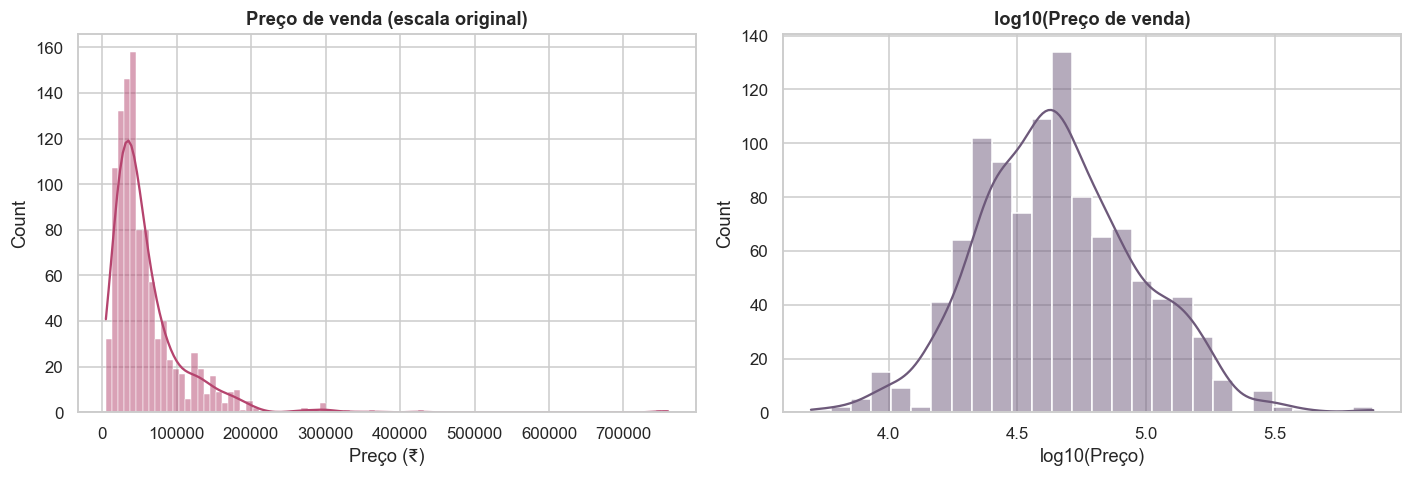

In [3]:
from src.descriptive_stats import tabela_descritiva
display(tabela_descritiva(df))
from src.visualization import plot_distribuicao_preco
_ = plot_distribuicao_preco(df)
plt.show()

## 3. EDA avançada
### 3.1 Outliers e correlação
A correlação de Spearman (monotônica) capta a depreciação não-linear que a de Pearson subestima.

,outliers_iqr,outliers_iqr_%,outliers_zscore,outliers_zscore_%
variavel,,,,
selling_price,87,8.28,13,1.24
km_driven,33,3.14,20,1.90
age,26,2.47,17,1.62


,pearson_r,pearson_p,spearman_r,spearman_p
variavel,,,,
age,-0.40,0.00,-0.70,0.00
km_driven,-0.39,0.00,-0.56,0.00
owner_num,0.00,0.91,-0.11,0.00
km_por_ano,-0.07,0.02,0.03,0.41


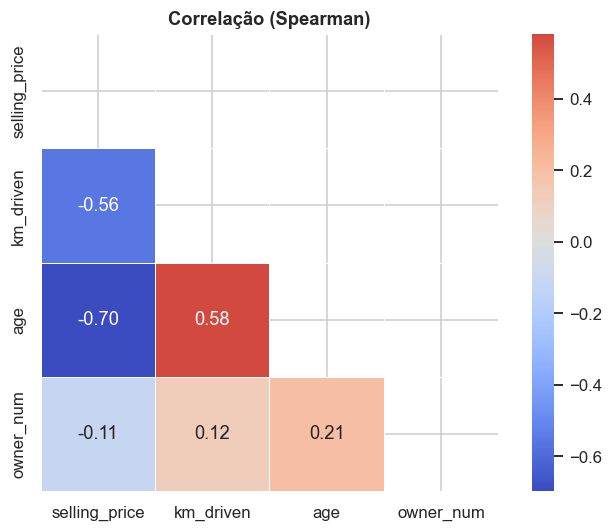

In [4]:
from src.eda_advanced import (resumo_outliers, matriz_correlacao,
                              analise_bivariada_preco, preco_por_marca)
display(resumo_outliers(df))
display(analise_bivariada_preco(df))
from src.visualization import plot_matriz_correlacao
_ = plot_matriz_correlacao(matriz_correlacao(df, 'spearman'), 'Correlação (Spearman)')
plt.show()

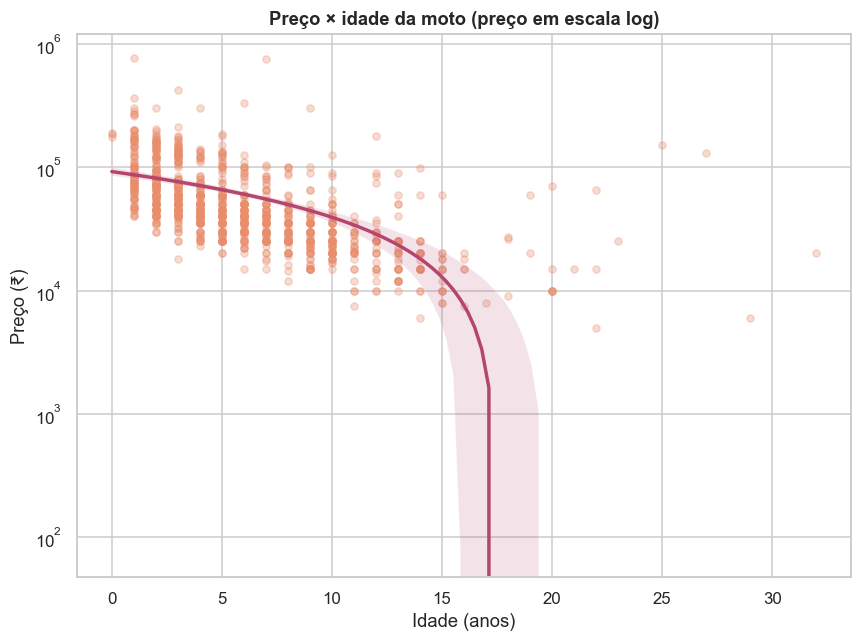

,n_motos,preco_medio,preco_mediano,idade_media,resale_ratio_medio
brand,,,,,
Royal Enfield,108,"128,628.70","124,000.00",5.17,0.81
Yamaha,102,"63,656.86","55,500.00",5.29,0.69
Honda,200,"45,069.42","42,000.00",5.20,0.67
Bajaj,260,"44,990.38","40,000.00",6.79,0.59
TVS,68,"46,835.40","35,000.00",6.38,0.56
Hero,229,"34,685.59","30,900.00",7.61,0.65


C:\Users\costd\OneDrive\Documentos\universidade dos dados\Motorcycle\src\visualization.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dados["preco_mediano"], y=dados.index.astype(str), ax=ax, palette="flare")


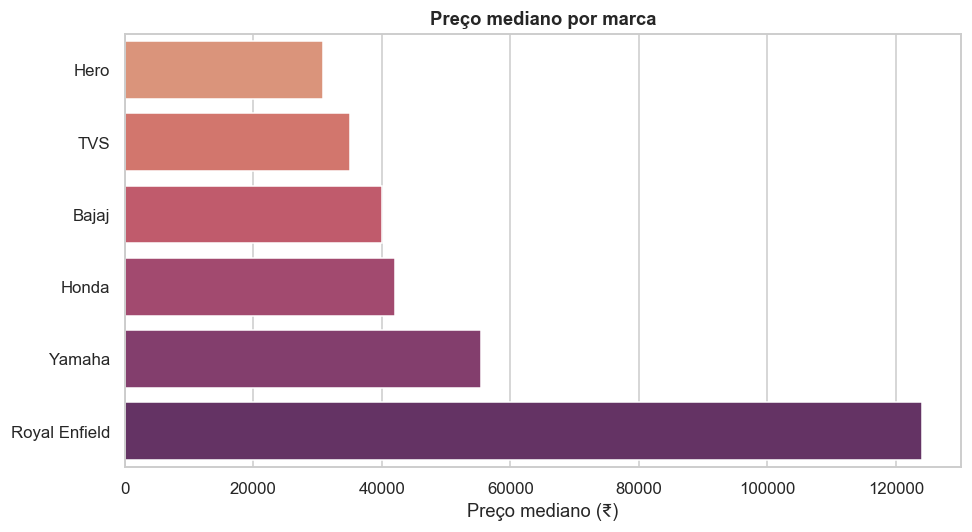

In [5]:
from src.visualization import plot_preco_vs_idade, plot_preco_por_marca
_ = plot_preco_vs_idade(df)
plt.show()
resumo_marcas = preco_por_marca(df)
display(resumo_marcas)
_ = plot_preco_por_marca(resumo_marcas)
plt.show()

## 4. Estatística inferencial
Teste t (1º dono vs demais) · ANOVA (preço por marca) · Intervalos de confiança

In [6]:
from src.inferential_stats import (teste_t_primeiro_dono, anova_marcas,
                                   tabela_intervalos_confianca)
print(teste_t_primeiro_dono(df))
print(anova_marcas(df))
display(tabela_intervalos_confianca(df))

[Teste t 1º dono (selling_price)] estatística=0.3716, p-valor=0.7107 -> Sem diferença significativa (1º dono=60,186 vs demais=57,481).
[ANOVA preço x marca] estatística=169.1521, p-valor=4.629e-129 -> Ao menos uma marca tem preço médio distinto (marca tem valor de mercado).


,media,ic95_t_inferior,ic95_t_superior,ic95_boot_inferior,ic95_boot_superior
variavel,,,,,
selling_price,"59,838.33","56,421.58","63,255.09","56,558.87","63,277.75"
km_driven,"30,215.15","28,838.55","31,591.75","28,833.13","31,675.54"
age,6.10,5.84,6.36,5.84,6.37


## 5. Modelagem
### 5.1 Regressão Linear (OLS sobre log do preço)

In [7]:
from src.modeling import treinar_regressao_linear, treinar_random_forest, segmentar_kmeans
reg = treinar_regressao_linear(df)
print(f'R2 treino={reg.r2_treino:.3f} | teste={reg.r2_teste:.3f}\n')
reg.coeficientes.round(4)

R2 treino=0.670 | teste=0.685



,coeficiente,p_valor,ic_inferior,ic_superior
const,11.22,0.00,11.11,11.33
age,-0.08,0.00,-0.09,-0.08
km_driven,-0.00,0.00,-0.00,-0.00
owner_num,0.05,0.20,-0.03,0.12
brand_Hero,-0.09,0.03,-0.18,-0.01
brand_Honda,-0.07,0.12,-0.16,0.02
brand_Outras,0.52,0.00,0.40,0.64
brand_Royal Enfield,0.99,0.00,0.88,1.09
brand_TVS,-0.11,0.09,-0.23,0.02
brand_Yamaha,0.22,0.00,0.10,0.33


### 5.2 Random Forest — o linear é difícil de superar
Em escala log, a relação é essencialmente linear: o RF não supera a OLS.

Random Forest R2 teste = 0.657



age                   0.49
km_driven             0.20
brand_Royal Enfield   0.17
brand_Outras          0.05
owner_num             0.03
brand_Honda           0.02
brand_Hero            0.01
brand_Yamaha          0.01
brand_TVS             0.01
dtype: float64

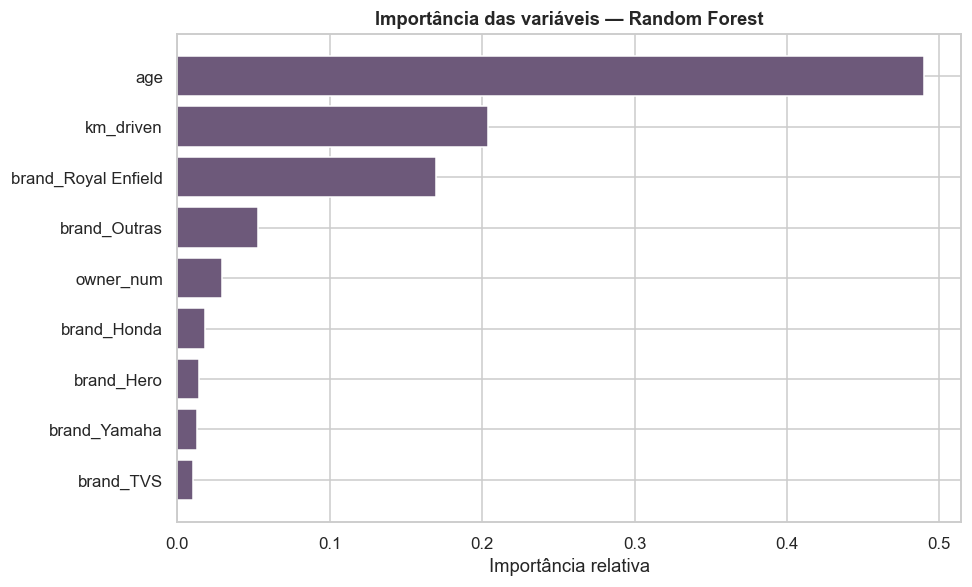

In [8]:
rf = treinar_random_forest(df)
print(f'Random Forest R2 teste = {rf.r2_teste:.3f}\n')
display(rf.importancias)
from src.visualization import plot_importancias
_ = plot_importancias(rf.importancias)
plt.show()

### 5.3 K-Means — segmentos de mercado

Silhouette = 0.375



,n_motos,preco_medio,idade_media,km_medio
cluster,,,,
0,551,"52,309.20",4.40,"21,705.90"
1,130,"165,369.20",2.40,"10,288.10"
2,128,"45,898.40",8.50,"36,911.20"
3,242,"27,664.00",10.60,"56,752.50"


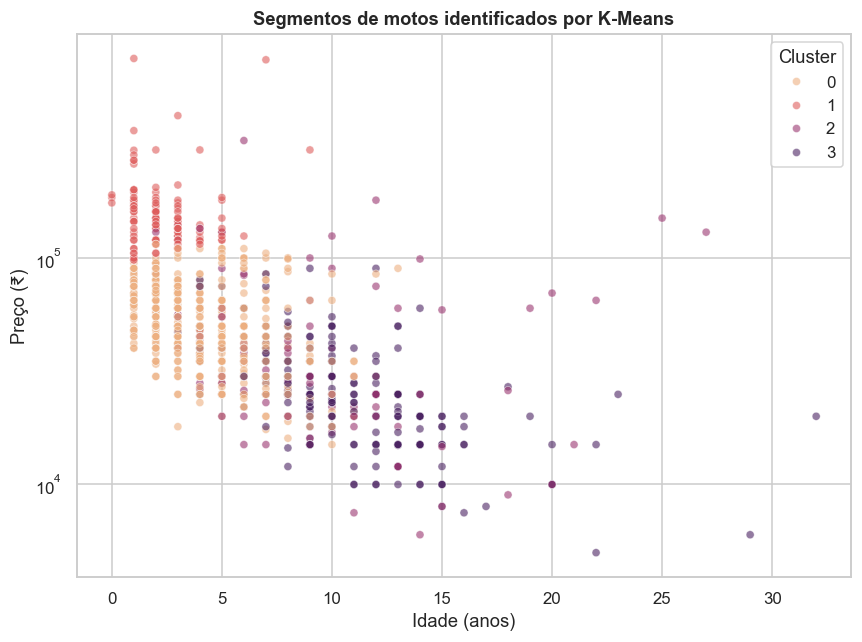

In [9]:
clu = segmentar_kmeans(df)
print(f'Silhouette = {clu.silhouette:.3f}\n')
display(clu.perfil_clusters)
from src.visualization import plot_clusters
_ = plot_clusters(clu.df_clusterizado)
plt.show()

## 6. Conclusões

- 📉 A **idade** é o maior driver da depreciação (~−8%/ano; Spearman −0,70).
- 🏆 **Royal Enfield** retém muito mais valor (revenda a 81% da tabela).
- 👥 O **número de donos não afeta** o preço (teste t p = 0,71) — mito desmentido.
- 🤖 Modelo sólido (**R² ≈ 0,68**); o Random Forest não supera o linear em escala log.
- 🧩 O mercado se divide em 4 segmentos, de premium/seminovas a antigas/rodadas.

> Pipeline completo: `python main.py` na raiz do projeto.